# Feature Engineering Pipeline (Robust & No-Leakage)

Questo notebook implementa una pipeline completa di Feature Engineering per il dataset GUIDE (Microsoft Incident Prediction).

**Obiettivo:** Trasformare i dati grezzi (livello Evidence) in un dataset pronto per il Machine Learning (livello Incident), mantenendo una rigorosa separazione tra Train e Test per evitare Data Leakage.

**Step Principali:**
1.  **Caricamento:** Importazione di `GUIDE_Train` e `GUIDE_Test`.
2.  **Target Engineering:** Definizione della variabile target (Binary: TruePositive vs Altri).
3.  **Evidence-Level Engineering:**
    *   Encoding Temporale
    *   *Smoothed Risk Score* (Calcolato su Train, applicato a Test)
    *   *Frequency Encoding* (Calcolato su Train, applicato a Test)
    *   Parsing Tecniche MITRE
4.  **Incident-Level Aggregation:** Aggregazione delle evidenze per ottenere una riga per Incidente.
5.  **Visual Analysis & Undersampling:** Analisi delle correlazioni e bilanciamento delle classi.
6.  **Export:** Salvataggio dei dataset processati.

In [1]:
import pandas as pd
import numpy as np
import os
import pickle
from collections import Counter
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.utils import resample
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Configurazioni
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
%matplotlib inline
sns.set_style('whitegrid')

# Percorsi
DATA_DIR = '../data'
OUTPUT_DIR = '../data/processed_final'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Setup completato. Output directory:", OUTPUT_DIR)

Setup completato. Output directory: ../data/processed_final


## 1. Caricamento Dati

In [2]:
print("Caricamento dataset...")
# Carichiamo i dataset originali
train_df = pd.read_csv(os.path.join(DATA_DIR, 'GUIDE_Train.csv'))
test_df = pd.read_csv(os.path.join(DATA_DIR, 'GUIDE_Test.csv'))

print(f"Train shape: {train_df.shape}")
print(f"Test shape: {test_df.shape}")

Caricamento dataset...
Train shape: (9516837, 45)
Test shape: (4147992, 46)


## 2. Pulizia e Preparazione Iniziale
Rimuoviamo le righe senza target nel training set e definiamo la variabile target binaria.

In [3]:
# Rimuovi righe senza IncidentGrade nel Train (se presenti)
train_df = train_df.dropna(subset=['IncidentGrade'])

# Definizione Target Binario: 1 se TruePositive, 0 altrimenti
train_df['Target'] = (train_df['IncidentGrade'] == 'TruePositive').astype(int)

# Per il Test set, se IncidentGrade è presente lo usiamo per validazione, altrimenti sarà NaN
if 'IncidentGrade' in test_df.columns:
    test_df['Target'] = (test_df['IncidentGrade'] == 'TruePositive').astype(int)
else:
    test_df['Target'] = np.nan

print("Target distribution (Train):")
print(train_df['Target'].value_counts(normalize=True))

Target distribution (Train):
Target
0    0.648966
1    0.351034
Name: proportion, dtype: float64


## 3. Feature Engineering (Evidence Level)

In questa fase creiamo nuove feature per ogni evidenza. 
**Regola d'oro:** Qualsiasi statistica globale (medie, frequenze) deve essere calcolata SOLO sul Train e poi applicata (mappata) sul Test.

### 3.1 Features Temporali

In [4]:
def extract_time_features(df):
    df['Timestamp'] = pd.to_datetime(df['Timestamp'])
    df['Hour'] = df['Timestamp'].dt.hour
    df['DayOfWeek'] = df['Timestamp'].dt.dayofweek
    df['IsWeekend'] = (df['DayOfWeek'] >= 5).astype(int)
    return df

train_df = extract_time_features(train_df)
test_df = extract_time_features(test_df)
print("Features temporali estratte.")

Features temporali estratte.


### 3.2 Smoothed Risk Encoding (Target Encoding)
Calcoliamo la probabilità che un certo `AlertTitle` sia un True Positive. Usiamo lo *smoothing* per evitare overfitting su categorie rare.
Calcoliamo la mappa su `train_df` e la applichiamo a entrambi.

In [5]:
# Parametri per smoothing bayesiano
alpha = 5  # Prior weight
global_mean = train_df['Target'].mean()

# Calcolo statistiche su TRAIN
stats = train_df.groupby('AlertTitle')['Target'].agg(['count', 'mean'])
smoothed_score = (stats['count'] * stats['mean'] + alpha * global_mean) / (stats['count'] + alpha)
risk_map = smoothed_score.to_dict()

# Applicazione
train_df['AlertRisk'] = train_df['AlertTitle'].map(risk_map).fillna(global_mean)
test_df['AlertRisk'] = test_df['AlertTitle'].map(risk_map).fillna(global_mean)

print("Smoothed Risk calcolato e applicato.")

Smoothed Risk calcolato e applicato.


### 3.3 Frequency Encoding & GeoLocation
Codifichiamo variabili categoriche ad alta cardinalità con la loro frequenza nel training set.

In [6]:
# Creazione feature combinata Geografica
for df in [train_df, test_df]:
    df['GeoLoc'] = df['CountryCode'].astype(str) + '_' + df['State'].astype(str) + '_' + df['City'].astype(str)

# Colonne da codificare in frequenza
freq_cols = ['GeoLoc', 'DeviceName', 'FileName', 'IpAddress', 'Url']

for col in freq_cols:
    # Calcola frequenza su TRAIN
    freq_map = train_df[col].value_counts(normalize=True).to_dict()
    
    # Applica (con 0 per valori nuovi nel test)
    train_df[f'{col}_Freq'] = train_df[col].map(freq_map).fillna(0)
    test_df[f'{col}_Freq'] = test_df[col].map(freq_map).fillna(0)

print(f"Frequency encoding applicato su: {freq_cols}")

Frequency encoding applicato su: ['GeoLoc', 'DeviceName', 'FileName', 'IpAddress', 'Url']


### 3.4 MITRE Techniques Processing
Estraiamo le tecniche più comuni (Top 20) e creiamo flag binari.

In [7]:
# Parsing della colonna (stringa separata da ;)
def parse_techniques(series):
    return series.fillna('').astype(str).apply(lambda x: x.split(';') if x else [])

train_techs = parse_techniques(train_df['MitreTechniques'])
test_techs = parse_techniques(test_df['MitreTechniques'])

# Identifica le Top 20 tecniche nel TRAIN
all_train_techs = [t for sublist in train_techs for t in sublist if t]
top_techs = [t[0] for t in Counter(all_train_techs).most_common(20)]

print("Top MITRE Techniques:", top_techs)

# One-Hot Encoding manuale per le top tecniche
for tech in top_techs:
    clean_tech_name = tech.replace('.', '_') # Pulisci nome colonna
    train_df[f'Mitre_{clean_tech_name}'] = train_df['MitreTechniques'].apply(lambda x: 1 if pd.notna(x) and tech in str(x) else 0)
    test_df[f'Mitre_{clean_tech_name}'] = test_df['MitreTechniques'].apply(lambda x: 1 if pd.notna(x) and tech in str(x) else 0)

# Conteggio totale tecniche
train_df['Mitre_Count'] = train_techs.apply(len)
test_df['Mitre_Count'] = test_techs.apply(len)

Top MITRE Techniques: ['T1078', 'T1078.004', 'T1566.002', 'T1566', 'T1110', 'T1133', 'T1566.001', 'T1110.003', 'T1110.001', 'T1071', 'T1046', 'T1087', 'T1087.002', 'T1190', 'T1098', 'T1210', 'T1559', 'T1059.005', 'T1568', 'T1008']


## 4. Aggregazione a Livello di Incidente
Ora comprimiamo le righe. Ogni `IncidentId` avrà una sola riga nel dataset finale. 
Le features delle evidenze verranno aggregate (media, somma, max, ecc.).

In [8]:
def aggregate_incidents(df):
    # Definiamo il dizionario di aggregazione
    agg_dict = {
        'Target': 'max',  # Se almeno una evidenza è TP, l'incidente è TP (o first, dato che è costante per incidente)
        'AlertId': 'nunique', # Numero di alert unici
        'Id': 'count',        # Numero totale di evidenze
        'AlertRisk': ['mean', 'max'],
        'Hour': ['mean', 'std'],
        'IsWeekend': 'mean', # % di evidenze nel weekend
        'Mitre_Count': 'sum',
        'OrgId': 'first', # L'organizzazione è costante per incidente
    }
    
    # Aggiungi aggregazioni per colonne frequenza
    for col in freq_cols:
        agg_dict[f'{col}_Freq'] = ['mean', 'max']
        
    # Aggiungi aggregazioni per colonne MITRE (somma = conteggio presenza)
    mitre_cols = [c for c in df.columns if c.startswith('Mitre_') and c != 'Mitre_Count']
    for col in mitre_cols:
        agg_dict[col] = 'max' # Basta che la tecnica appaia una volta nell'incidente

    # Esegui GroupBy
    print("Esecuzione aggregazione...")
    df_agg = df.groupby('IncidentId').agg(agg_dict)
    
    # Appiattisci i nomi delle colonne (es. AlertRisk_mean)
    df_agg.columns = ['_'.join(col).strip() for col in df_agg.columns.values]
    df_agg.reset_index(inplace=True)
    
    # Rinomina alcune colonne chiave
    df_agg.rename(columns={'Target_max': 'Target', 'Id_count': 'EvidenceCount', 'AlertId_nunique': 'AlertCount'}, inplace=True)
    
    return df_agg

print("Aggregazione Train Set...")
train_agg = aggregate_incidents(train_df)

print("Aggregazione Test Set...")
test_agg = aggregate_incidents(test_df)

print(f"Train Aggregated Shape: {train_agg.shape}")
print(f"Test Aggregated Shape: {test_agg.shape}")

Aggregazione Train Set...
Esecuzione aggregazione...
Aggregazione Test Set...
Esecuzione aggregazione...
Train Aggregated Shape: (448901, 41)
Test Aggregated Shape: (236267, 41)


## 5. Visual Analysis & Undersampling
Verifichiamo l'utilità delle feature e bilanciamo le classi.

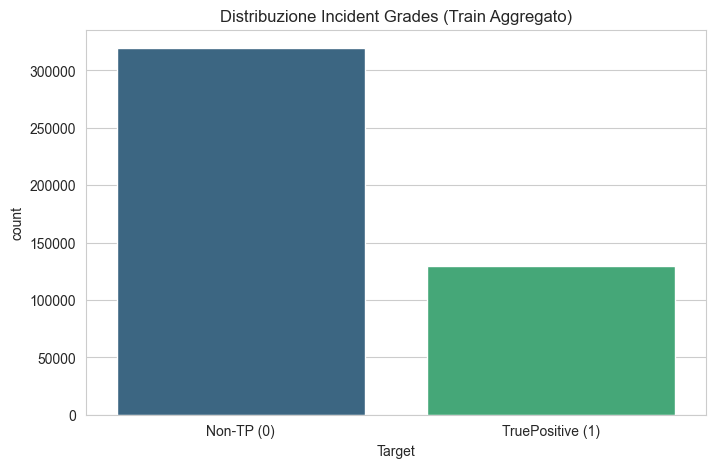

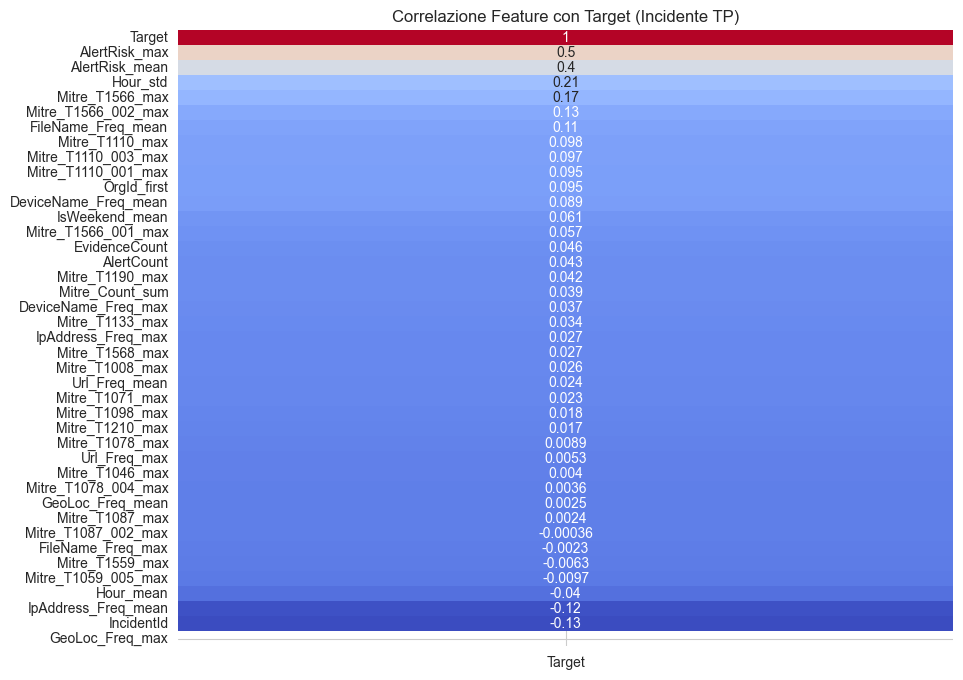

Top 10 Feature Correlate positivamente:
Target                 1.000000
AlertRisk_max          0.500635
AlertRisk_mean         0.401219
Hour_std               0.207823
Mitre_T1566_max        0.172710
Mitre_T1566_002_max    0.129935
FileName_Freq_mean     0.105603
Mitre_T1110_max        0.097743
Mitre_T1110_003_max    0.097494
Mitre_T1110_001_max    0.095440
Name: Target, dtype: float64


In [9]:
# Analisi Distribuzione Classi
plt.figure(figsize=(8, 5))
sns.countplot(x='Target', data=train_agg, palette='viridis')
plt.title('Distribuzione Incident Grades (Train Aggregato)')
plt.xticks([0, 1], ['Non-TP (0)', 'TruePositive (1)'])
plt.show()

# Analisi Correlazione con il Target
# Selezioniamo solo colonne numeriche per la correlazione
numeric_cols = train_agg.select_dtypes(include=[np.number]).columns
correlation = train_agg[numeric_cols].corr()['Target'].sort_values(ascending=False)

plt.figure(figsize=(10, 8))
sns.heatmap(correlation.to_frame(), annot=True, cmap='coolwarm', cbar=False)
plt.title('Correlazione Feature con Target (Incidente TP)')
plt.show()

print("Top 10 Feature Correlate positivamente:")
print(correlation.head(10))

In [10]:
# --- UNDERSAMPLING ---
print("Esecuzione Undersampling della classe maggioritaria...")

# Separazione classi
df_majority = train_agg[train_agg.Target == 0]
df_minority = train_agg[train_agg.Target == 1]

print(f"Classe Maggioritaria (0): {len(df_majority)}")
print(f"Classe Minoritaria (1): {len(df_minority)}")

# Shuffle e Undersample della maggioritaria
# Nota: resample esegue lo shuffle di default
df_majority_downsampled = resample(df_majority, 
                                   replace=False,    # sample without replacement
                                   n_samples=len(df_minority), # match minority class
                                   random_state=42) 

# Combinazione
train_balanced = pd.concat([df_majority_downsampled, df_minority])

# Shuffle finale del dataset combinato
train_balanced = train_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Nuova shape bilanciata: {train_balanced.shape}")
print(train_balanced['Target'].value_counts())

Esecuzione Undersampling della classe maggioritaria...
Classe Maggioritaria (0): 319558
Classe Minoritaria (1): 129343
Nuova shape bilanciata: (258686, 41)
Target
0    129343
1    129343
Name: count, dtype: int64


## 6. Salvataggio Output
Salviamo i file pronti per l'addestramento dei modelli. 
**Nota:** Salviamo sia la versione sbilanciata (`train_final.csv`) che quella bilanciata (`train_balanced.csv`) per poter sperimentare.

In [11]:
# Fill NaN generati dall'aggregazione (es. std su un solo elemento)
train_agg.fillna(0, inplace=True)
train_balanced.fillna(0, inplace=True)
test_agg.fillna(0, inplace=True)

# Salvataggio
train_agg.to_csv(os.path.join(OUTPUT_DIR, 'train_final_imbalanced.csv'), index=False)
train_balanced.to_csv(os.path.join(OUTPUT_DIR, 'train_final_balanced.csv'), index=False)
test_agg.to_csv(os.path.join(OUTPUT_DIR, 'test_final.csv'), index=False)

# Salvataggio delle mappature per inferenza futura
mappings = {
    'risk_map': risk_map,
    'top_techs': top_techs,
    'global_mean': global_mean
}
with open(os.path.join(OUTPUT_DIR, 'feature_mappings.pkl'), 'wb') as f:
    pickle.dump(mappings, f)

print("Dataset e mappature salvati in ", OUTPUT_DIR)

Dataset e mappature salvati in  ../data/processed_final
